In [2]:
import geopandas as gpd
import folium
from folium import GeoJson
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import contextily as cx

In [6]:

gdf = gpd.read_file("/Volumes/ukiki/3.code/dallas_crime/data/census/census_merged_fine.gpkg")


In [ ]:
# Read tl_2010_48_place10 shapefile (Texas places from 2010 Census)
texas_places = gpd.read_file("/Volumes/ukiki/3.code/dallas_crime/data/census/tl_2010_48_place10")

# Check CRS and basic info
print(f"CRS: {texas_places.crs}")
print(f"Number of places: {len(texas_places)}")
print(f"Columns: {texas_places.columns.tolist()}")
print(f"\nFirst few rows:")
print(texas_places.head())

# Filter for Dallas city
dallas_place = texas_places[texas_places["NAME10"] == "Dallas"]
print(f"\nDallas city found: {len(dallas_place) > 0}")
if len(dallas_place) > 0:
    print(dallas_place[["NAME10", "PLACEFP10", "geometry"]].head())

In [7]:
# Check CRS
print(f"CRS: {gdf.crs}")
print(f"Has CRS: {gdf.crs is not None}")
if gdf.crs is not None:
    print(f"EPSG code: {gdf.crs.to_epsg()}")
    print(f"CRS name: {gdf.crs.name}")


CRS: EPSG:4269
Has CRS: True
EPSG code: 4269
CRS name: NAD83


In [ ]:
# Convert to Web Mercator (EPSG:3857)
if gdf.crs is None or gdf.crs.to_epsg() != 3857:
    gdf = gdf.to_crs(epsg=3857)


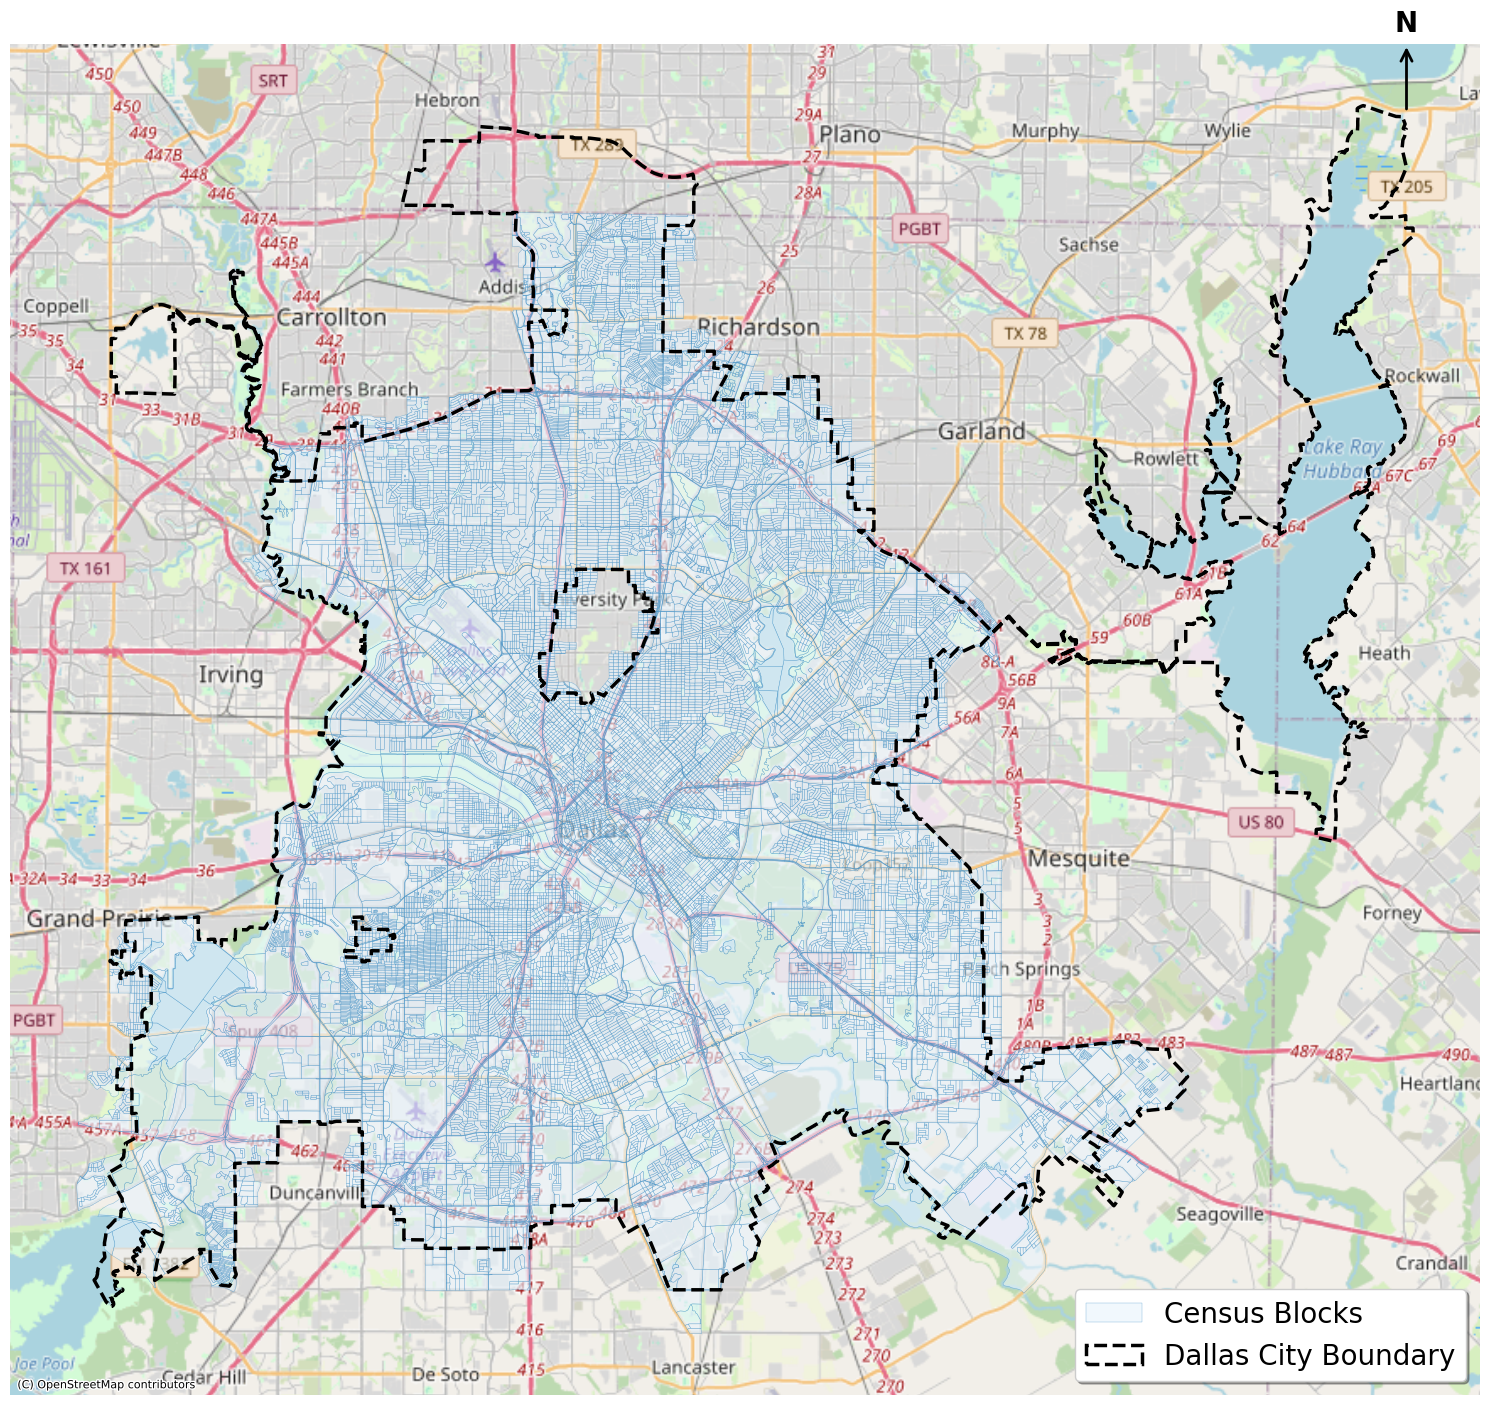

In [40]:
# Get Dallas city boundary from texas_places (loaded in cell 2)
dallas_boundary = texas_places[texas_places["NAME10"] == "Dallas"].copy()
# Convert to same CRS as gdf (EPSG:3857)
if dallas_boundary.crs.to_epsg() != 3857:
    dallas_boundary = dallas_boundary.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(15, 15))

# Plot census blocks first
gdf.plot(ax=ax, facecolor="#E8F4FD", edgecolor="#2E86C1", linewidth=0.3, alpha=0.6)

# Add Dallas city boundary
dallas_boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2.5, linestyle="--")

# Add OpenStreetMap basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=11, crs=gdf.crs)

# Create custom legend handles
census_patch = mpatches.Patch(facecolor="#E8F4FD", edgecolor="#2E86C1", linewidth=0.3, alpha=0.6, label="Census Blocks")
boundary_line = mpatches.Patch(facecolor="none", edgecolor="black", linewidth=2.5, linestyle="--", label="Dallas City Boundary")

# Add legend (bottom right)
ax.legend(handles=[census_patch, boundary_line], loc="lower right", frameon=True, fancybox=True, shadow=True, fontsize=20)

# Add north arrow (upper right)
# Get the bounds of the plot
xlim = ax.get_xlim()
ylim = ax.get_ylim()
# Position arrow in upper right corner
arrow_x = xlim[1] - (xlim[1] - xlim[0]) * 0.05
arrow_y = ylim[1] - (ylim[1] - ylim[0]) * 0.05
arrow_length = (ylim[1] - ylim[0]) * 0.05

# Draw north arrow
north_arrow = FancyArrowPatch(
    (arrow_x, arrow_y),
    (arrow_x, arrow_y + arrow_length),
    arrowstyle="->", 
    mutation_scale=20,
    linewidth=2,
    color="black"
)
ax.add_patch(north_arrow)
# Add "N" label
ax.text(arrow_x, arrow_y + arrow_length * 1.1, "N", fontsize=20, fontweight="bold", 
        ha="center", va="bottom", color="black")

# Remove axes and save/show the plot
ax.set_axis_off()
plt.tight_layout()


# Save as PDF
plt.savefig("/Volumes/ukiki/3.code/dallas_crime/data/plots/biz_map/dallas_map_biz.pdf", dpi=300, bbox_inches="tight", format="pdf")


# plt.show()